# 03 · Evaluate, compare and demo

Uses only `models/`, `results/` and `data/test/`; no retraining.

In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import confusion_matrix

from classifier.compare import COLUMNS, load_metrics, load_report, save_comparison
from classifier.data import load_split, pick_device
from classifier.plots import plot_comparison, plot_confusion
from classifier.predict import identify, load_model, predict_proba

RESULTS = ROOT / "results"
MODELS = ROOT / "models"
device = pick_device()
test = load_split(ROOT / "data").query("split == 'test'").reset_index(drop=True)
print(f"device {device} | {len(test)} test images")

device mps | 535 test images


## Model comparison

In [2]:
metrics = load_metrics(RESULTS)
save_comparison(metrics, RESULTS)
BEST = metrics.model.iloc[0]
print("best model:", BEST)
metrics.style.format({c: "{:.2%}" for c in COLUMNS[3:9]}).highlight_max(subset=["test_acc", "test_macro_f1"], color="#c6efce")

best model: EfficientNetB0


,model,params_M,epochs_run,best_val_acc,test_acc,test_top5,test_macro_precision,test_macro_recall,test_macro_f1,train_time_min,inference_ms_per_img
0,EfficientNetB0,4.060000,15,99.81%,99.25%,99.81%,99.29%,99.25%,99.25%,11.980000,10.860000
1,MobileNetV3,4.250000,15,99.44%,99.25%,99.63%,99.30%,99.25%,99.24%,7.650000,7.070000
2,ResNet18,11.200000,15,99.44%,98.69%,99.63%,98.77%,98.70%,98.68%,8.430000,4.660000
3,SimpleCNN,1.180000,40,70.65%,67.85%,92.52%,69.12%,67.84%,66.44%,25.730000,4.270000


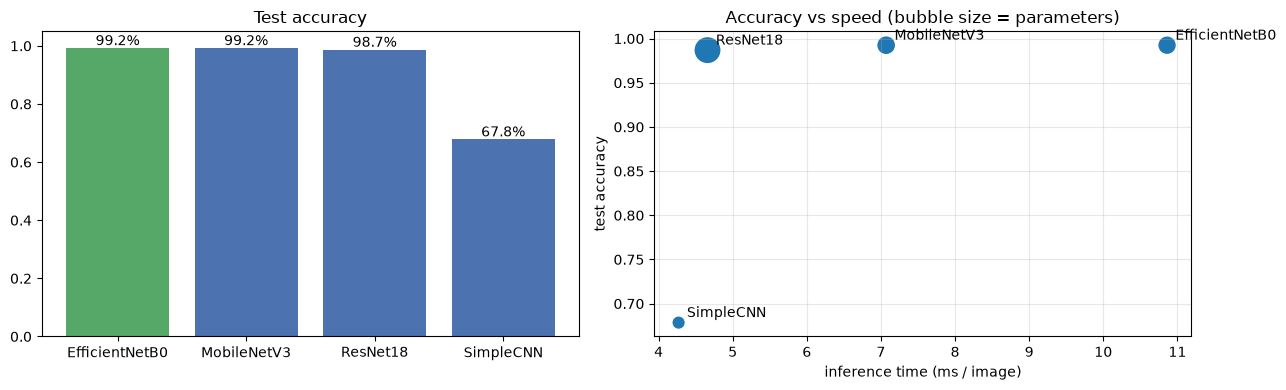

In [3]:
plot_comparison(metrics, RESULTS / "model_comparison.png")
plt.show()

## Error analysis

In [4]:
model, classes = load_model(MODELS / f"{BEST}.pt", device)
probs = predict_proba(model, test.path.tolist(), device)
test["pred"] = [classes[i] for i in probs.argmax(1)]
test["conf"] = probs.max(1).values.numpy()
wrong = test[test.pred != test.label]
print(f"{BEST}: {len(wrong)} / {len(test)} misclassified -> accuracy {1 - len(wrong) / len(test):.2%}")

EfficientNetB0: 4 / 535 misclassified -> accuracy 99.25%


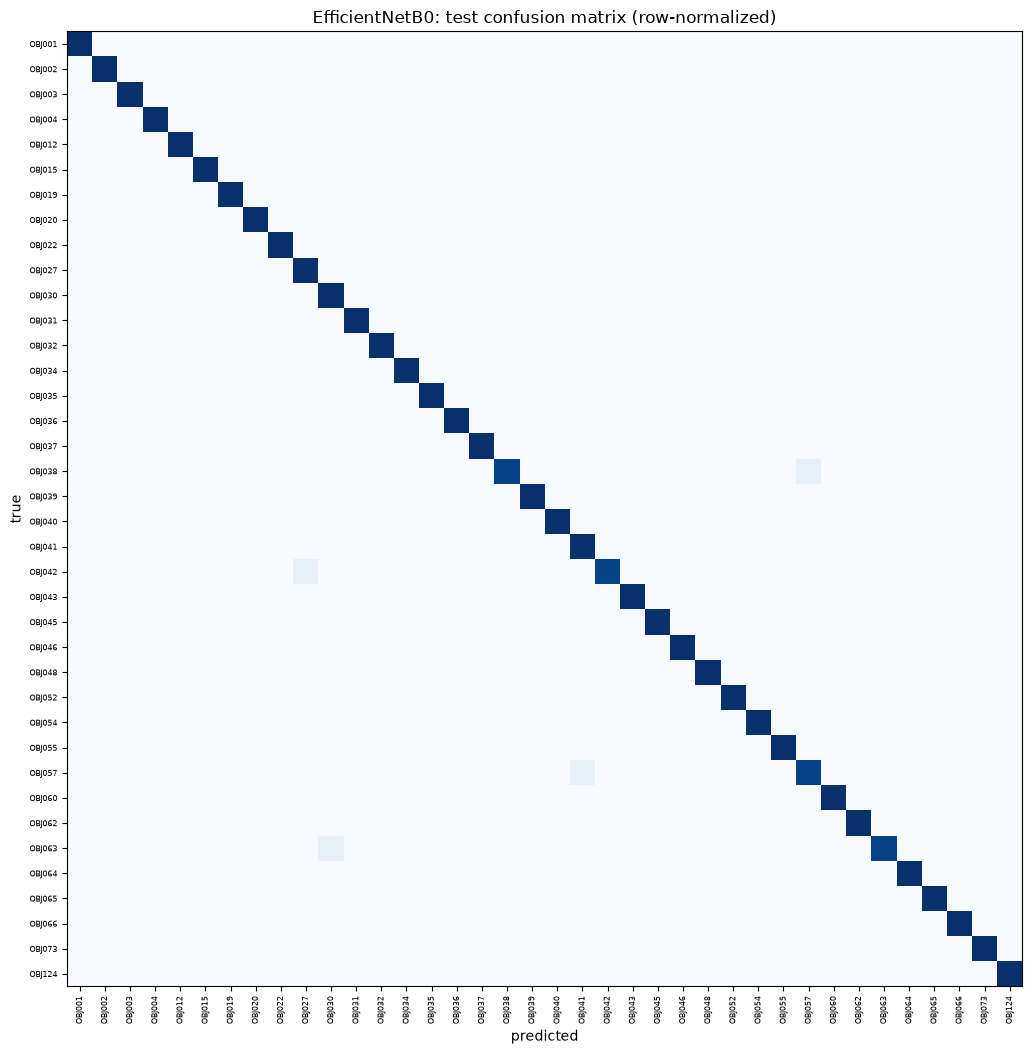

In [5]:
plot_confusion(confusion_matrix(test.label, test.pred, labels=classes), classes,
               RESULTS / f"{BEST}_confusion_matrix.png", f"{BEST}: test confusion matrix (row-normalized)")
plt.show()

In [6]:
per_cls = pd.DataFrame(load_report(RESULTS, BEST)["per_class"]).T
per_cls.sort_values("f1-score").head(8).round(3)

,precision,recall,f1-score,support
OBJ057,0.929,0.929,0.929,14.0
OBJ038,1.000,0.929,0.963,14.0
OBJ042,1.000,0.929,0.963,14.0
OBJ063,1.000,0.929,0.963,14.0
OBJ027,0.933,1.000,0.966,14.0
OBJ030,0.933,1.000,0.966,14.0
OBJ041,0.933,1.000,0.966,14.0
OBJ062,1.000,1.000,1.000,14.0


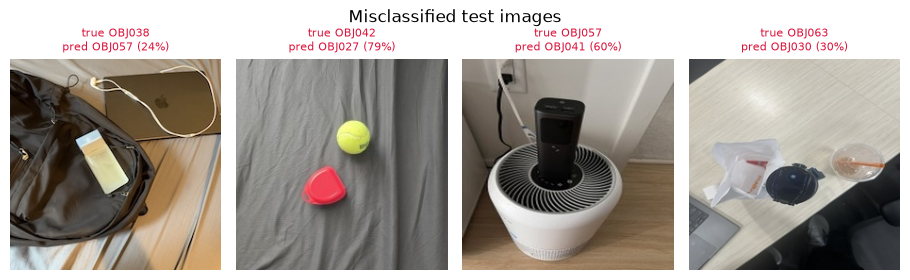

In [7]:
if len(wrong):
    show = wrong.head(12)
    fig, axes = plt.subplots(1, len(show), figsize=(2.3 * len(show), 2.9), squeeze=False)
    for ax, r in zip(axes[0], show.itertuples()):
        ax.imshow(Image.open(r.path)); ax.axis("off")
        ax.set_title(f"true {r.label}\npred {r.pred} ({r.conf:.0%})", fontsize=8, color="crimson")
    plt.suptitle("Misclassified test images"); plt.tight_layout(); plt.show()
else:
    print("no misclassified test images")

In [8]:
baseline = pd.DataFrame(load_report(RESULTS, "SimpleCNN")["per_class"]).T
pd.DataFrame({"SimpleCNN F1": baseline["f1-score"], f"{BEST} F1": per_cls["f1-score"]}).round(3).sort_values("SimpleCNN F1").head(8)

,SimpleCNN F1,EfficientNetB0 F1
OBJ038,0.261,0.963
OBJ062,0.286,1.000
OBJ042,0.364,0.963
OBJ034,0.381,1.000
OBJ057,0.400,0.929
OBJ052,0.400,1.000
OBJ003,0.414,1.000
OBJ039,0.444,1.000


## Demo

Set `IMAGE_PATH` to any photo, or leave it `None` to sample six test images.

/Users/anshumansingh/Documents/deep_learning/project_1/milestone1/data/test/OBJ048/OBJ048_069.jpg -> OBJ048 90.3%, OBJ064 0.9%, OBJ041 0.7%
/Users/anshumansingh/Documents/deep_learning/project_1/milestone1/data/test/OBJ060/OBJ060_024.jpg -> OBJ060 95.1%, OBJ045 0.4%, OBJ052 0.2%
/Users/anshumansingh/Documents/deep_learning/project_1/milestone1/data/test/OBJ039/OBJ039_002.jpg -> OBJ039 92.7%, OBJ065 0.4%, OBJ030 0.3%
/Users/anshumansingh/Documents/deep_learning/project_1/milestone1/data/test/OBJ042/OBJ042_060.jpg -> OBJ042 93.9%, OBJ031 0.9%, OBJ020 0.8%
/Users/anshumansingh/Documents/deep_learning/project_1/milestone1/data/test/OBJ042/OBJ042_035.jpg -> OBJ042 92.6%, OBJ063 1.4%, OBJ032 1.3%
/Users/anshumansingh/Documents/deep_learning/project_1/milestone1/data/test/OBJ124/OBJ124_069.jpg -> OBJ124 95.8%, OBJ063 0.3%, OBJ073 0.2%


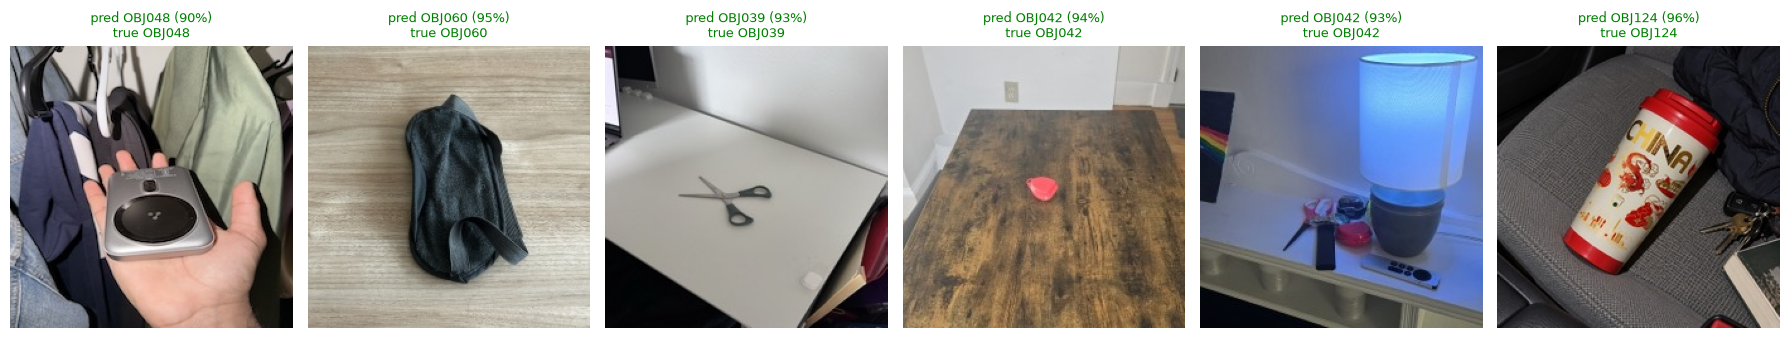

In [9]:
IMAGE_PATH = None

samples = [IMAGE_PATH] if IMAGE_PATH else test.sample(6, random_state=1).path.tolist()
fig, axes = plt.subplots(1, len(samples), figsize=(3 * len(samples), 3.4), squeeze=False)
for ax, p in zip(axes[0], samples):
    top = identify(model, classes, p, device)
    true = Path(p).parent.name.removeprefix("images_")
    known = true.startswith("OBJ")
    ax.imshow(Image.open(p)); ax.axis("off")
    ax.set_title(f"pred {top[0][0]} ({top[0][1]:.0%})" + (f"\ntrue {true}" if known else ""),
                 fontsize=9, color="green" if not known or top[0][0] == true else "crimson")
    print(p, "->", ", ".join(f"{c} {q:.1%}" for c, q in top))
plt.tight_layout(); plt.show()

## Conclusion

| Model | Test acc. | Macro F1 | Params | ms / image | Train time |
|---|---|---|---|---|---|
| **EfficientNet-B0** | **99.25%** | **0.993** | 4.06 M | 10.9 | 12.0 min |
| MobileNetV3-Large | 99.25% | 0.992 | 4.25 M | 7.1 | 7.7 min |
| ResNet18 | 98.69% | 0.987 | 11.2 M | 4.7 | 8.4 min |
| SimpleCNN (scratch) | 67.85% | 0.664 | 1.18 M | 4.3 | 25.7 min |

*38 classes, 535 test images, Apple M4 (MPS).*

- **Transfer learning is decisive.** Pretrained backbones reach ~99% in 15 epochs; the scratch CNN stalls at ~68% after 40, since ~67 training images per class is too few to learn features from nothing.
- **Best model: EfficientNet-B0** (highest macro F1, 4 / 535 errors, 4M params). MobileNetV3 ties on errors and is ~35% faster.
- **All 4 errors are cluttered scenes containing another class's object** (e.g. an OBJ042 photo also showing OBJ027). A single-label classifier cannot resolve these, which motivates multi-object detection.

**Limitations:** ~14 test images per class, so the gaps between the top three models (≤ 3 images) are not significant. Results cover 38 of 73 objects. Test photos come from the same sessions as the training photos, so accuracy on new photos will likely be lower.